# Core 

> Core functions of elastic library

In [1]:
#| default_exp core

In [2]:
#| hide
from nbdev.showdoc import *

Elastic is a library for calculation of $C_{ij}$ components of elastic
tensor from the strain-stress relation.

The strain components here are ordered in standard way which is different
to ordering in previous versions of the code (up to 4.0).
The ordering is: $u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}$.

The general ordering of $C_{ij}$ components is (except for triclinic
symmetry and taking into account customary names of constants - e.g. $C_{16} \rightarrow C_{14}$ ):

$$
   C_{11}, C_{22}, C_{33}, C_{12}, C_{13}, C_{23},
   C_{44}, C_{55}, C_{66}, C_{16}, C_{26}, C_{36}, C_{45}
$$

The functions with the name of bravais lattices define the symmetry of the
$C_{ij}$ matrix. The matrix is N columns by 6 rows where the columns
corespond to independent elastic constants of the given crystal, while the rows
corespond to the canonical deformations of a crystal. The elements are the
second partial derivatives of the free energy formula for the crystal written
down as a quadratic form of the deformations with respect to elastic constant
and deformation.

*Note:*
The elements for deformations $u_{xy}, u_{xz}, u_{yz}$
have to be divided by 2 to properly match the usual definition
of elastic constants.

See: [@LL] L.D. Landau, E.M. Lifszyc, "Theory of elasticity", and also some usefull summary at 
[ScienceWorld](http://scienceworld.wolfram.com/physics/Elasticity.html).

In [3]:
#| exporti
from ase.atoms import Atoms

try:
    # Try new release of spglib
    import spglib as spg
except ImportError:
    # Old naming scheme
    from pyspglib import spglib as spg

from scipy.linalg import norm, lstsq
from scipy import optimize
from numpy.linalg import inv
from numpy import dot, diag, ones, reshape, linspace, array, mean, ndarray
import numpy as np
from math import acos, pi, cos, sin, sqrt, exp
from typing import Union

In [4]:
#| exporti
from ase.spacegroup import crystal
from matplotlib import pylab as plt

## Equation of state

These functions define equation of state (EOS) for the crystal in the $P(V)$ formulation. All EOS functions used in Elastic must accept one argument - volume (`float` or `ndarray`) and three unified parameters: 

* $V_0$ - Volume at zero pressure
* $K$ - Bulk compressibility at $V_0$
* $K'$ - derivative of the bulk compressibility at $V_0$

The return value should be pressure as the same type as argument (i.e. `float` or `ndarray`).
The code below implements three commonly used equations of state after 

K. Latimer, S. Dwaraknath, K. Mathew, D. Winston, and K. A. Persson,  
*Evaluation of thermodynamic equations of state across chemistry and 
structure in the materials project*,  
Npj Comput Mater 4, 1 (2018); doi:10.1038/s41524-018-0091-x

Here are the P(V, V0, K, K') variants of those EOSs

* Murnaghan
* Birch-Murnaghan
* Vinet (default)

Different EOS can be easily implemented and used following these examples.

In [5]:
#| export

def vinet(v:float|ndarray,  
            v0:float,  
            K:float,  
            Kp:float
         )->float|ndarray:
    '''
    Vinet equation of state function in P(V) formulation.

    Parameters
    ----------
    v
        volume(s)
    v0
        volume at zero pressure
    K
        bulk compressibility at v0
    Kp
        derivative of the bulk compressibility at v0

    Returns
    -------
    pressure
        Pressure at volume(s) v
    '''
    c = 3*(Kp-1)/2
    x = (v/v0)**(1/3)
    return 3*K*(1-x)*np.exp(c*(1-x))/(x**2)

In [6]:
#| export

def murnaghan(v:float|ndarray,  
         v0:float,  
         K:float,  
         Kp:float
        )->float|ndarray:
    '''
    Murnaghan equation of state function in P(V) formulation.

    Parameters
    ----------
    v
        volume(s)
    v0
        volume at zero pressure
    K
        bulk compressibility at v0
    Kp
        derivative of the bulk compressibility at v0

    Returns
    -------
    pressure
        Pressure at volume(s) v
    '''
    x = v/v0
    return K*(x**(-Kp) - 1)/Kp

In [7]:
#| export

def birch_murnaghan(v:float|ndarray,  
            v0:float,  
            K:float,  
            Kp:float
         )->float|ndarray:
    '''
    Birch-Murnaghan equation of state function in P(V) formulation.

    Parameters
    ----------
    v
        volume(s)
    v0
        volume at zero pressure
    K
        bulk compressibility at v0
    Kp
        derivative of the bulk compressibility at v0

    Returns
    -------
    pressure
        Pressure at volume(s) v
    '''
    b = 9*K/8
    c = Kp-4
    x = (v/v0)**(1/3)
    return 3*K*(x**(-7)-x**(-5))*(1+3*(Kp-4)*(x**(-2)-1)/4)/2

In [8]:
#| exporti

def ctg(x:float)->float:
    '''
    Cotangens function
    '''
    return np.cos(x)/np.sin(x)


def csc(x:float)->float:
    '''
    Cosecans function
    '''
    return 1/np.sin(x)

## The shape of the equation of state

Check the difference between defined EOS functions by plotting them against each other for $V_0=1$.

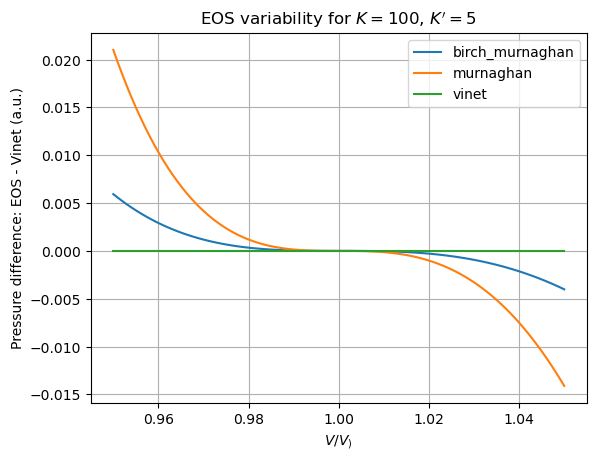

In [9]:
v = linspace(0.95, 1.05, 100)
K = 100
Kp = 5
for eos in birch_murnaghan, murnaghan, vinet:
    plt.plot(v, eos(v, 1, K, Kp)-vinet(v, 1, K, Kp), label=eos.__name__)
plt.grid()
plt.legend()
plt.xlabel('$V/V_)$')
plt.ylabel('Pressure difference: EOS - Vinet (a.u.)')
plt.title(f"EOS variability for $K=${K}, $K'=${Kp}");

## Equation matrix generators

The following functions are used to generate equation matrix $S(s)$ taking into account all symmetry relations imposed by the symmetry of the crystal. The functions take the vector of vectors of deformation
$[ u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy} ]$ (each $u_{ij}$ is a vector of all computed deformations). Thus the `u` argument is in fact $6\times N$ array of calculated deformations.

The return value is an array of $k\times 6\times N$ coefficients of the $S^a$ matrix (see `Physical Priciples` section) with symmetry relations taken into account. The size of the `k` index is equal to the number of independent components of the elastic tensor for a given crystal (symmetry). The order of the components of the elastic tensor is determined by the order of the columns in the returned array.

In [10]:
#| export
def regular(u:ndarray)->ndarray:
    '''
    Equation generator for the regular (cubic) lattice.
    The order of constants: $$C_{11}, C_{12}, C_{44}$$

    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''
    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
               [[uxx,   uyy + uzz,      0],
                [uyy,   uxx + uzz,      0],
                [uzz,   uxx + uyy,      0],
                [0,             0,      2*uyz],
                [0,             0,      2*uxz],
                [0,             0,      2*uxy]])

In [11]:
#| export
def tetragonal(u:ndarray)->ndarray:
    '''
    Equation matrix generation for the tetragonal lattice.
    The order of constants: $$C_{11}, C_{33}, C_{12}, C_{13}, C_{44}, C_{66}$$

    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
                [[uxx,   0,    uyy,  uzz,      0,      0],
                 [uyy,   0,    uxx,  uzz,      0,      0],
                 [0,     uzz,  0,    uxx+uyy,  0,      0],
                 [0,     0,    0,    0,        2*uxz,  0],
                 [0,     0,    0,    0,        2*uyz,  0],
                 [0,     0,    0,    0,        0,      2*uxy]])

In [12]:
#| export
def orthorombic(u:ndarray)->ndarray:
    '''
    Equation matrix generation for the orthorombic lattice.
    The order of constants:
    $$
       C_{11}, C_{22}, C_{33}, C_{12}, C_{13}, C_{23},
       C_{44}, C_{55}, C_{66}
    $$
    
    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
                [[uxx,     0,    0,  uyy,  uzz,    0,     0,     0,     0],
                 [0,     uyy,    0,  uxx,    0,  uzz,     0,     0,     0],
                 [0,       0,  uzz,    0,  uxx,  uyy,     0,     0,     0],
                 [0,       0,    0,    0,    0,    0, 2*uyz,     0,     0],
                 [0,       0,    0,    0,    0,    0,     0, 2*uxz,     0],
                 [0,       0,    0,    0,    0,    0,     0,     0, 2*uxy]])

In [13]:
#| export
def trigonal(u:ndarray)->ndarray:
    '''
    The matrix is constructed based on the approach from L&L
    using auxiliary coordinates: $\\xi=x+iy$, $\\eta=x-iy$.
    The components are calculated from free energy using formula
    introduced in :ref:`symmetry` with appropriate coordinate changes.
    The order of constants:
    $$
       C_{11}, C_{33}, C_{12}, C_{13}, C_{44}, C_{14}
    $$
    
    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    # TODO: Not tested yet.
    # TODO: There is still some doubt about the C_{14} constant.
    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
                [[   uxx,   0,    uyy,     uzz,     0,   2*uxz      ],
                 [   uyy,   0,    uxx,     uzz,     0,  -2*uxz      ],
                 [     0, uzz,      0, uxx+uyy,     0,   0          ],
                 [     0,   0,      0,       0, 2*uyz,  -4*uxy      ],
                 [     0,   0,      0,       0, 2*uxz,   2*(uxx-uyy)],
                 [ 2*uxy,   0, -2*uxy,       0,     0,  -4*uyz      ]])

In [14]:
#| export
def hexagonal(u:ndarray)->ndarray:
    '''
    The matrix is constructed based on the approach from L&L
    using auxiliary coordinates: $\\xi=x+iy$, $\\eta=x-iy$.
    The components are calculated from free energy using formula
    introduced in :ref:`symmetry` with appropriate coordinate changes.
    The order of constants is as follows:
    $$
       C_{11}, C_{33}, C_{12}, C_{13}, C_{44}
    $$
    
    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    # TODO: Still needs good verification
    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
                [[   uxx,   0,    uyy,     uzz,     0   ],
                 [   uyy,   0,    uxx,     uzz,     0   ],
                 [     0, uzz,      0, uxx+uyy,     0   ],
                 [     0,   0,      0,       0, 2*uyz   ],
                 [     0,   0,      0,       0, 2*uxz   ],
                 [   uxy,   0,   -uxy,       0,     0   ]])

In [15]:
#| export
def monoclinic(u:ndarray)->ndarray:
    '''
    Equation matrix generation for the Monoclinic lattice,
    The ordering of constants:
    $$
       C_{11}, C_{22}, C_{33}, C_{12}, C_{13}, C_{23},
       C_{44}, C_{55}, C_{66}, C_{16}, C_{26}, C_{36}, C_{45}
    $$
    
    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
                [[uxx,  0,  0,uyy,uzz,  0,    0,    0,    0,uxy,  0,  0,  0],
                 [  0,uyy,  0,uxx,  0,uzz,    0,    0,    0,  0,uxy,  0,  0],
                 [  0,  0,uzz,  0,uxx,uyy,    0,    0,    0,  0,  0,uxy,  0],
                 [  0,  0,  0,  0,  0,  0,2*uyz,    0,    0,  0,  0,  0,uxz],
                 [  0,  0,  0,  0,  0,  0,    0,2*uxz,    0,  0,  0,  0,uyz],
                 [  0,  0,  0,  0,  0,  0,    0,    0,2*uxy,uxx,uyy,uzz,  0]])

In [16]:
#| export
def triclinic(u:ndarray)->ndarray:
    '''
    Equation matrix generation for the Triclinic crystals.
    The ordering of constants:
    $$
       C_{11}, C_{22}, C_{33}, 
       C_{12}, C_{13}, C_{23}, 
       C_{44}, C_{55}, C_{66}, 
    $$
    $$
       C_{16}, C_{26}, C_{36}, C_{46}, C_{56},
       C_{14}, C_{15}, C_{25}, C_{45}
    $$
    **Note**: This was never tested on the real case. Beware!
    
    Parameters
    ----------
    u
        array of deformations (6xN): $[u_{xx}, u_{yy}, u_{zz}, u_{yz}, u_{xz}, u_{xy}]$

    Returns
    -------
    eq. matrix
        Symmetry defined stress-strain equation matrix (#k x 6 x N)
    '''

    # Based on the monoclinic matrix and not tested on real case.
    # If you have test cases for this symmetry send them to the author.
    uxx, uyy, uzz, uyz, uxz, uxy = u[0], u[1], u[2], u[3], u[4], u[5]
    return array(
    [[uxx,  0,  0,uyy,uzz,  0,    0,    0,    0,uxy,  0,  0,  0,  0,uyz,uxz,  0,  0],
     [  0,uyy,  0,uxx,  0,uzz,    0,    0,    0,  0,uxy,  0,  0,  0,  0,  0,uxz,  0],
     [  0,  0,uzz,  0,uxx,uyy,    0,    0,    0,  0,  0,uxy,  0,  0,  0,  0,  0,  0],
     [  0,  0,  0,  0,  0,  0,2*uyz,    0,    0,  0,  0,  0,uxy,  0,uxx,  0,  0,uxz],
     [  0,  0,  0,  0,  0,  0,    0,2*uxz,    0,  0,  0,  0,  0,uxy,  0,uxx,uyy,uyz],
     [  0,  0,  0,  0,  0,  0,    0,    0,2*uxy,uxx,uyy,uzz,uyz,uxz,  0,  0,  0,  0]])

## Lattice information functions

These fonctions provide information about varius aspects of the crystal lattice

In [17]:
#| export
def get_cij_order(cryst:Atoms)->tuple:
    '''
    Give order of of elastic constants for the structure

    Parameters
    ----------
    cryst
        ASE Atoms object

    Returns
    -------
    returns 
        Order of elastic constants as a tuple of strings: C_ij
    '''

    orders = {
            1: ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23',
                'C_44', 'C_55', 'C_66', 'C_16', 'C_26', 'C_36',
                'C_46', 'C_56', 'C_14', 'C_15', 'C_25', 'C_45'),
            2: ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23',
                'C_44', 'C_55', 'C_66', 'C_16', 'C_26', 'C_36', 'C_45'),
            3: ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23', 'C_44',
                'C_55', 'C_66'),
            4: ('C_11', 'C_33', 'C_12', 'C_13', 'C_44', 'C_66'),
            5: ('C_11', 'C_33', 'C_12', 'C_13', 'C_44', 'C_14'),
            6: ('C_11', 'C_33', 'C_12', 'C_13', 'C_44'),
            7: ('C_11', 'C_12', 'C_44'),
            }
    return orders[get_lattice_type(cryst)[0]]

In [18]:
#| export
def get_lattice_type(cryst:Atoms)->tuple:
    '''
    Find the symmetry of the crystal using spglib symmetry finder.
    Derive name of the space group and its number extracted from the result.
    Based on the group number identify also the lattice type and the Bravais
    lattice of the crystal. 

    Notes
    -----
        The lattice type numbers are (the numbering starts from 1):
    
        1. Triclinic
        2. Monoclinic
        3. Orthorombic
        4. Tetragonal
        5. Trigonal
        6. Hexagonal
        7. Cubic    

    Parameters
    ----------
    cryst
        ASE Atoms object

    Returns
    -------
    returns 
        tuple (lattice type number (1-7), lattice name, space group
                     name, space group number)
    '''

    # Table of lattice types and correcponding group numbers dividing
    # the ranges. See get_lattice_type method for precise definition.
    lattice_types = [
            [3,   "Triclinic"],
            [16,  "Monoclinic"],
            [75,  "Orthorombic"],
            [143, "Tetragonal"],
            [168, "Trigonal"],
            [195, "Hexagonal"],
            [231, "Cubic"]
        ]

    cell = (cryst.cell, cryst.get_scaled_positions(), cryst.numbers)
    dataset = spg.get_symmetry_dataset(cell)
    sg_name = dataset.international
    sg_nr = dataset.number

    for n, l in enumerate(lattice_types):
        if sg_nr < l[0]:
            bravais = l[1]
            lattype = n+1
            break

    return lattype, bravais, sg_name, sg_nr

In [19]:
from ase.lattice import cubic, tetragonal, orthorhombic, monoclinic, triclinic, hexagonal

In [20]:
for cryst in (cubic.Diamond('C'),
              cubic.BodyCenteredCubic('Fe'),
              orthorhombic.BaseCenteredOrthorhombic('C', latticeconstant={'a':1, 'b':2, 'c':2.5}),
              monoclinic.BaseCenteredMonoclinic('C', latticeconstant={'a':1, 'b':2, 'c':3, 'alpha':60}),
              triclinic.Triclinic('C', latticeconstant={'a':1, 'b':2, 'c':3, 'alpha':60, 'beta':40, 'gamma':75})
             ):
    print(get_lattice_type(cryst), get_cij_order(cryst))

(7, 'Cubic', 'Fd-3m', 227) ('C_11', 'C_12', 'C_44')
(7, 'Cubic', 'Im-3m', 229) ('C_11', 'C_12', 'C_44')
(3, 'Orthorombic', 'Cmmm', 65) ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23', 'C_44', 'C_55', 'C_66')
(2, 'Monoclinic', 'C2/m', 12) ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23', 'C_44', 'C_55', 'C_66', 'C_16', 'C_26', 'C_36', 'C_45')
(1, 'Triclinic', 'P-1', 2) ('C_11', 'C_22', 'C_33', 'C_12', 'C_13', 'C_23', 'C_44', 'C_55', 'C_66', 'C_16', 'C_26', 'C_36', 'C_46', 'C_56', 'C_14', 'C_15', 'C_25', 'C_45')


In [21]:
from hypothesis import given, assume
from hypothesis.strategies import integers, floats, builds

In [22]:
def build_crystal(a, b, c, al, be, ga):
    from ase.atoms import Atoms
    if (al+be+ga > 350): return
    if (al+be < 1.1*ga): return
    if (al+ga < 1.1*be): return
    if (be+ga < 1.1*al): return

    atms = Atoms('Mg', positions=[(0, 0, 0)],
                 cell=[a, b, c, al, be, ga], pbc=True)
    atms._test_data = [a, b, c, al*pi/180, be*pi/180, ga*pi/180]
    return atms


crystals = builds(build_crystal,
                  a=floats(min_value=1.0, max_value=20.0),
                  b=floats(min_value=1.0, max_value=20.0),
                  c=floats(min_value=1.0, max_value=20.0),
                  al=floats(min_value=15.0, max_value=120.0),
                  be=floats(min_value=15.0, max_value=120.0),
                  ga=floats(min_value=15.0, max_value=120.0),
                  )

In [23]:
@given(cr=crystals)
def test_lattice_type(cr):
    assume(cr is not None)
    assert get_lattice_type(cr)[0] in (1, 2, 3, 4, 5, 6, 7)

test_lattice_type()

## Lattice manipulation functions

These functions modify the shape of the crystal

In [24]:
#| export
def get_elementary_deformations(cryst, n=5, d=2):
    '''Generate elementary deformations for elastic tensor calculation.

    The deformations are created based on the symmetry of the crystal and
    are limited to the non-equivalet axes of the crystal.

    :param cryst: Atoms object, basic structure
    :param n: integer, number of deformations per non-equivalent axis
    :param d: float, size of the maximum deformation in percent and degrees

    :returns: list of deformed structures
    '''
    # Deformation look-up table
    # Perhaps the number of deformations for trigonal
    # system could be reduced to [0,3] but better safe then sorry
    deform = {
        "Cubic": [[0, 3], regular],
        "Hexagonal": [[0, 2, 3, 5], hexagonal],
        "Trigonal": [[0, 1, 2, 3, 4, 5], trigonal],
        "Tetragonal": [[0, 2, 3, 5], tetragonal],
        "Orthorombic": [[0, 1, 2, 3, 4, 5], orthorombic],
        "Monoclinic": [[0, 1, 2, 3, 4, 5], monoclinic],
        "Triclinic": [[0, 1, 2, 3, 4, 5], triclinic]
    }

    lattyp, brav, sg_name, sg_nr = get_lattice_type(cryst)
    # Decide which deformations should be used
    axis, symm = deform[brav]

    systems = []
    for a in axis:
        if a < 3:  # tetragonal deformation
            for dx in linspace(-d, d, n):
                systems.append(
                        get_cart_deformed_cell(cryst, axis=a, size=dx))
        elif a < 6:  # sheer deformation (skip the zero angle)
            for dx in linspace(d/10.0, d, n):
                systems.append(
                        get_cart_deformed_cell(cryst, axis=a, size=dx))
    return systems

In [25]:
#| export
def get_cart_deformed_cell(base_cryst, axis=0, size=1):
    '''Return the cell deformed along one of the cartesian directions

    Creates new deformed structure. The deformation is based on the
    base structure and is performed along single axis. The axis is
    specified as follows: 0,1,2 = x,y,z ; sheers: 3,4,5 = yz, xz, xy.
    The size of the deformation is in percent and degrees, respectively.

    :param base_cryst: structure to be deformed
    :param axis: direction of deformation
    :param size: size of the deformation

    :returns: new, deformed structure
    '''
    cryst = Atoms(base_cryst)
    uc = base_cryst.get_cell()
    s = size/100.0
    L = diag(ones(3))
    if axis < 3:
        L[axis, axis] += s
    else:
        if axis == 3:
            L[1, 2] += s
        elif axis == 4:
            L[0, 2] += s
        else:
            L[0, 1] += s
    uc = dot(uc, L)
    cryst.set_cell(uc, scale_atoms=True)
    # print(cryst.get_cell())
    # print(uc)
    return cryst

In [26]:
#| export
def get_bulk_modulus(cryst):
    '''Calculate bulk modulus using the Birch-Murnaghan equation of state.

    The EOS must be previously calculated by get_BM_EOS routine.
    The returned bulk modulus is a :math:`B_0` coefficient of the B-M EOS.
    The units of the result are defined by ASE. To get the result in
    any particular units (e.g. GPa) you need to divide it by
    ase.units.<unit name>::

        get_bulk_modulus(cryst)/ase.units.GPa

    :param cryst: ASE Atoms object

    :returns: float, bulk modulus :math:`B_0` in ASE units.
    '''

    if getattr(cryst, 'bm_eos', None) is None:
        raise RuntimeError('Missing B-M EOS data.')
    cryst.bulk_modulus = cryst.bm_eos[1]
    return cryst.bulk_modulus

In [27]:
#| export
def get_pressure(s):
    '''Return *external* isotropic (hydrostatic) pressure in ASE units.

    If the pressure is positive the system is under external pressure.
    This is a convenience function to convert output of get_stress function
    into external pressure.

    :param cryst: stress tensor in Voight (vector) notation as returned by
        the get_stress() method.

    :returns: float, external hydrostatic pressure in ASE units.
    '''

    return -mean(s[:3])

In [28]:
#| export
def get_BM_EOS(cryst, systems):
    """Calculate Birch-Murnaghan Equation of State for the crystal.

    The B-M equation of state is defined by:

    .. math::
       P(V)= \\frac{B_0}{B'_0}\\left[
       \\left({\\frac{V}{V_0}}\\right)^{-B'_0} - 1
       \\right]

    It's coefficients are estimated using n single-point structures ganerated
    from the crystal (cryst) by the scan_volumes function between two relative
    volumes. The BM EOS is fitted to the computed points by
    least squares method. The returned value is a list of fitted
    parameters: :math:`V_0, B_0, B_0'` if the fit succeded.
    If the fitting fails the ``RuntimeError('Calculation failed')`` is raised.
    The data from the calculation and fit is stored in the bm_eos and pv
    members of cryst for future reference. You have to provide properly
    optimized structures in cryst and systems list.

    :param cryst: Atoms object, basic structure
    :param systems: A list of calculated structures

    :returns: tuple of EOS parameters :math:`V_0, B_0, B_0'`.
    """

    pvdat = array([[r.get_volume(),
                    get_pressure(r.get_stress()),
                    norm(r.get_cell()[:, 0]),
                    norm(r.get_cell()[:, 1]),
                    norm(r.get_cell()[:, 2])] for r in systems]).T

    # Estimate the initial guess assuming b0p=1
    # Limiting volumes
    v1 = min(pvdat[0])
    v2 = max(pvdat[0])

    # The pressure is falling with the growing volume
    p2 = min(pvdat[1])
    p1 = max(pvdat[1])
    b0 = (p1*v1-p2*v2)/(v2-v1)
    v0 = v1*(p1+b0)/b0

    # Initial guess
    p0 = [v0, b0, 1]

    # Fitting
    try :
        p1, succ = optimize.curve_fit(BMEOS, pvdat[0], pvdat[1], p0)
    except (ValueError, RuntimeError, optimize.OptimizeWarning) as ex:
        raise RuntimeError('Calculation failed')

    cryst.bm_eos = p1
    cryst.pv = pvdat
    return cryst.bm_eos

In [28]:
#| export
def get_EOS(cryst, systems, eos=vinet):
    """Fit Equation of State (eos) for the crystal.

    The equation of state is defined as a function $P(V, V_0, K, K')$: `eos`.

    It's coefficients are estimated using n single-point structures ganerated
    from the crystal (cryst) by the scan_volumes function between two relative
    volumes. The EOS is fitted to the computed points by
    least squares method. The returned value is a list of fitted
    parameters: $V_0, K, K'$ if the fit succeded.
    If the fitting fails the `RuntimeError('Calculation failed')` is raised.
    You have to provide properly optimized structures in cryst 
    and systems list.

    Parameters
    ----------
    cryst
        Atoms object, basic structure
    systems 
        A list of calculated structures

    Returns
    -------
    fit parameters, p-v data
        Tuple of EOS parameters $V_0, K, K'$ and array of P-V data.
    """

    pvdat = array([[r.get_volume(),
                    get_pressure(r.get_stress()),
                    norm(r.get_cell()[:, 0]),
                    norm(r.get_cell()[:, 1]),
                    norm(r.get_cell()[:, 2])] for r in systems]).T

    # Estimate the initial guess assuming b0p=1
    # Limiting volumes
    v1 = min(pvdat[0])
    v2 = max(pvdat[0])

    # The pressure is falling with the growing volume
    p2 = min(pvdat[1])
    p1 = max(pvdat[1])
    b0 = (p1*v1-p2*v2)/(v2-v1)
    v0 = v1*(p1+b0)/b0

    # Initial guess
    p0 = [v0, b0, 1]

    # Fitting
    try :
        p1, succ = optimize.curve_fit(eos, pvdat[0], pvdat[1], p0)
    except (ValueError, RuntimeError, optimize.OptimizeWarning) as ex:
        raise RuntimeError('Calculation failed')

    return p1, pvdat

In [29]:
#| export
def get_elastic_tensor(cryst, systems):
    '''Calculate elastic tensor of the crystal.

    The elastic tensor is calculated from the stress-strain relation
    and derived by fitting this relation to the set of linear equations
    build from the symmetry of the crystal and strains and stresses
    of the set of elementary deformations of the unit cell.

    It is assumed that the crystal is converged and optimized
    under intended pressure/stress. The geometry and stress on the
    cryst is taken as the reference point. No additional optimization
    will be run. Structures in cryst and systems list must have calculated
    stresses. The function returns tuple of :math:`C_{ij}` elastic tensor,
    raw Birch coefficients :math:`B_{ij}` and fitting results: residuals,
    solution rank, singular values returned by numpy.linalg.lstsq.

    :param cryst: Atoms object, basic structure
    :param systems: list of Atoms object with calculated deformed structures

    :returns: tuple(:math:`C_{ij}` float vector,
                    tuple(:math:`B_{ij}` float vector, residuals, solution rank, singular values))
    '''

    # Deformation look-up table
    # Perhaps the number of deformations for trigonal
    # system could be reduced to [0,3] but better safe then sorry
    deform = {
        "Cubic": [[0, 3], regular],
        "Hexagonal": [[0, 2, 3, 5], hexagonal],
        "Trigonal": [[0, 1, 2, 3, 4, 5], trigonal],
        "Tetragonal": [[0, 2, 3, 5], tetragonal],
        "Orthorombic": [[0, 1, 2, 3, 4, 5], orthorombic],
        "Monoclinic": [[0, 1, 2, 3, 4, 5], monoclinic],
        "Triclinic": [[0, 1, 2, 3, 4, 5], triclinic]
    }

    lattyp, brav, sg_name, sg_nr = get_lattice_type(cryst)
    # Decide which deformations should be used
    axis, symm = deform[brav]

    ul = []
    sl = []
    p = get_pressure(cryst.get_stress())
    for g in systems:
        ul.append(get_strain(g, refcell=cryst))
        # Remove the ambient pressure from the stress tensor
        sl.append(g.get_stress()-array([p, p, p, 0, 0, 0]))
    # print(symm, ul)
    eqm = array([symm(u) for u in ul])
    # print(eqm)
    # print(eqm[0].shape, eqm.shape)
    eqm = reshape(eqm, (eqm.shape[0]*eqm.shape[1], eqm.shape[2]))
    # print(eqm)
    slm = reshape(array(sl), (-1,))
    # print(eqm.shape, slm.shape)
    # print(slm)
    Bij = lstsq(eqm, slm)
    # print(Bij[0] / units.GPa)
    # Calculate elastic constants from Birch coeff.
    # TODO: Check the sign of the pressure array in the B <=> C relation
    if (symm == orthorombic):
        Cij = Bij[0] - array([-p, -p, -p, p, p, p, -p, -p, -p])
    elif (symm == tetragonal):
        Cij = Bij[0] - array([-p, -p, p, p, -p, -p])
    elif (symm == regular):
        Cij = Bij[0] - array([-p, p, -p])
    elif (symm == trigonal):
        Cij = Bij[0] - array([-p, -p, p, p, -p, p])
    elif (symm == hexagonal):
        Cij = Bij[0] - array([-p, -p, p, p, -p])
    elif (symm == monoclinic):
        # TODO: verify this pressure array
        Cij = Bij[0] - array([-p, -p, -p, p, p, p, -p, -p, -p, p, p, p, p])
    elif (symm == triclinic):
        # TODO: verify this pressure array
        Cij = Bij[0] - array([-p, -p, -p, p, p, p, -p, -p, -p,
                              p, p, p, p, p, p, p, p, p])
    return Cij, Bij

In [30]:
#| export
def scan_pressures(cryst, lo, hi, n=5, eos=None):
    '''
    Scan the pressure axis from lo to hi (inclusive)
    using B-M EOS as the volume predictor.
    Pressure (lo, hi) in GPa
    '''
    # Inverse B-M EOS to get volumes from pressures
    # This will work only in limited pressure range p>-B/B'.
    # Warning! Relative, the V0 prefactor is removed.
    def invbmeos(b, bp, x):
        return array([pow(b/(bp*xv+b), 1/(3*bp)) for xv in x])

    if eos is None:
        raise RuntimeError('Required EOS data missing')

    # Limit negative pressures to 90% of the singularity value.
    # Beyond this B-M EOS is bound to be wrong anyway.
    lo = max(lo, -0.9*eos[1]/eos[2])

    scale = (eos[0]/cryst.get_volume())*invbmeos(eos[1], eos[2],
                                                 linspace(lo, hi, num=n))
    # print(scale)
    uc = cryst.get_cell()
    systems = [Atoms(cryst) for s in scale]
    for n, s in enumerate(scale):
        systems[n].set_cell(s*uc, scale_atoms=True)

    return systems

In [31]:
#| export
def scan_volumes(cryst, lo=0.98, hi=1.02, n=5, scale_volumes=True):
    '''
    Provide set of crystals along volume axis from lo to hi (inclusive).
    No volume cell optimization is performed. Bounds are specified as
    fractions (1.10 = 10% increase). If scale_volumes==False the scalling
    is applied to lattice vectors instead of volumes.

    :param lo: lower bound of the V/V_0 in the scan
    :param hi: upper bound of the V/V_0 in the scan
    :param n: number of volume sample points
    :param scale_volumes: If True scale the unit cell volume or,
                            if False, scale the length of lattice axes.

    :returns: a list of deformed systems
    '''
    scale = linspace(lo, hi, num=n)
    if scale_volumes:
        scale **= (1.0/3.0)
    uc = cryst.get_cell()
    systems = [Atoms(cryst) for s in scale]
    for n, s in enumerate(scale):
        systems[n].set_cell(s*uc, scale_atoms=True)
    return systems

In [32]:
@given(cr=crystals,
       lo=floats(min_value=0.1, max_value=1.0),
       hi=floats(min_value=1.0, max_value=2.0),
       n=integers(min_value=2, max_value=20),
       )
def test_volume_scan(cr, lo, hi, n):
    assume(cr is not None)
    cl = scan_volumes(cr, lo, hi, n, True)
    eps = 1e-6
    assert len(cl) == n
    assert np.allclose(cl[0].get_volume(), cr.get_volume()*lo)
    assert np.allclose(cl[-1].get_volume(), cr.get_volume()*hi)
    for c in cl[1:-1]:
        assert cr.get_volume()*lo <= c.get_volume() <= cr.get_volume()*hi

test_volume_scan()

In [33]:
#| export
def get_vecang_cell(cryst, uc=None):
    '''
    Compute A,B,C, alpha,beta,gamma cell params
    from the unit cell matrix (uc) or cryst.
    Angles in radians.
    '''
    if uc is None:
        uc = cryst.get_cell()
    ucv = [uc[i, :]/norm(uc[i, :]) for i in range(3)]
    uca = [acos(dot(ucv[(i+1) % 3], ucv[(i+2) % 3])) for i in range(3)]
    return [norm(uc[i, :]) for i in range(3)] + uca

In [34]:
@given(cr=crystals)
def test_lattice_vecang(cr):
    assume(cr is not None)
    assert np.allclose(get_vecang_cell(cr), cr._test_data)

test_lattice_vecang()

In [35]:
#| export
def get_deformed_cell(base_cryst, axis=0, size=1):
    '''
    Return the cell (with atoms) deformed along one
    cell parameter (0,1,2 = a,b,c ; 3,4,5 = alpha,beta,gamma) by
    size percent or size degrees (axis/angles).
    '''
    cryst = Atoms(base_cryst)
    uc = base_cryst.get_cell()
    if axis < 3:
        uc[axis, :] = (1+size/100.0)*uc[axis, :]
    else:
        (a, b, c, alp, bet, gam) = get_vecang_cell(cryst)
        d = array([0.0, 0.0, 0.0])
        d[axis-3] = pi*size/180
        (alp, bet, gam) = array((alp, bet, gam))+d
        t = 1 - (ctg(bet)*ctg(gam)-cos(alp)*csc(bet)*csc(gam))**2
        if t < 0.0:
            print('''
            The parameters (alpha,beta,gamma)=(%f,%f,%f) are probably
            incorrect and lead to imaginary coordinates.
            This range of parameters is unsupported by this program
            (and is, let me say, very strange for a crystal).
            Cennot continue, bye.''' % (alp, bet, gam))
            raise ValueError
        else:
            uc = [[a, 0.0, 0.0],
                  [b*cos(gam), b*sin(gam), 0],
                  [c*cos(bet),
                   c*(cos(alp)/sin(gam) - cos(bet)*ctg(gam)),
                   c*sin(bet)*sqrt(t)]]
    cryst.set_cell(uc, scale_atoms=True)
    # print(cryst.get_cell())
    # print(uc)
    return cryst

In [36]:
@given(cr=crystals,
       ax=integers(min_value=0, max_value=2),
       prc=floats(min_value=-90, max_value=90),
       )
def test_deform_shrink(cr, ax, prc):
    assume(cr is not None)
    dc = get_deformed_cell(cr, axis=ax, size=prc)
    assert np.allclose((dc.get_volume()/cr.get_volume()-1)*100, prc)
    assert np.allclose((dc.cell.cellpar()[ax]/cr._test_data[ax] - 1)*100, prc)

test_deform_shrink()

In [37]:
@given(cr=crystals,
       ax=integers(min_value=0, max_value=2),
       size=floats(min_value=-10, max_value=10),
       )
def test_deform_angels(cr, ax, size):
    assume(cr is not None)
    delta = np.zeros(3)
    delta[ax] = pi*size/180
    (alp, bet, gam) = array(cr._test_data[3:]) + delta
    # Guard against non-existing lattice vectors
    t = 1 - (ctg(bet)*ctg(gam)-cos(alp)*csc(bet)*csc(gam))**2
    assume(t > 1e-6)
    dc = get_deformed_cell(cr, axis=ax+3, size=size)
    assert np.allclose(pi*dc.cell.cellpar()[ax+3]/180,
                    cr._test_data[ax+3] + pi*size/180, atol=pi*1e-3/180)

test_deform_angels()

In [38]:
#| export
def get_strain(cryst, refcell=None):
    '''Calculate strain tensor in the Voight notation

    Computes the strain tensor in the Voight notation as a conventional
    6-vector. The calculation is done with respect to the crystal
    geometry passed in refcell parameter.

    :param cryst: deformed structure
    :param refcell: reference, undeformed structure

    :returns: 6-vector of strain tensor in the Voight notation
    '''
    if refcell is None:
        refcell = cryst
    du = cryst.get_cell()-refcell.get_cell()
    m = refcell.get_cell()
    m = inv(m)
    u = dot(m, du)
    u = (u+u.T)/2
    return array([u[0, 0], u[1, 1], u[2, 2], u[2, 1], u[2, 0], u[1, 0]])

In [39]:


a = 4.194
cryst = crystal(['Mg', 'O'],
                [(0, 0, 0), (0.5, 0.5, 0.5)],
                spacegroup=225,
                cellpar=[a, a, a, 90, 90, 90])

sl = scan_volumes(cryst)
print('Volumes: ', end='')
for c in sl:
    print('%.2f (%.1f%%)' % (c.get_volume(),
                             100*c.get_volume()/cryst.get_volume()),
          end=' ')

print()

sl = get_elementary_deformations(cryst)
print('Structures: ')
print('   Vol             A       B       C          alph    bet     gam')
for n, c in enumerate(sl):
    print('%.4f (%5.1f%%)' % (c.get_volume(),
                              100*c.get_volume()/cryst.get_volume()),
          end='')
    print((3*' %7.4f' + '  ' + 3*' %7.2f') %
          tuple(c.cell.cellpar()))

Volumes: 72.30 (98.0%) 73.03 (99.0%) 73.77 (100.0%) 74.51 (101.0%) 75.25 (102.0%) 
Structures: 
   Vol             A       B       C          alph    bet     gam
72.2955 ( 98.0%)  4.1101  4.1940  4.1940     90.00   90.00   90.00
73.0332 ( 99.0%)  4.1521  4.1940  4.1940     90.00   90.00   90.00
73.7709 (100.0%)  4.1940  4.1940  4.1940     90.00   90.00   90.00
74.5086 (101.0%)  4.2359  4.1940  4.1940     90.00   90.00   90.00
75.2464 (102.0%)  4.2779  4.1940  4.1940     90.00   90.00   90.00
73.7709 (100.0%)  4.1940  4.1940  4.1940     89.89   90.00   90.00
73.7709 (100.0%)  4.1940  4.1941  4.1940     89.63   90.00   90.00
73.7709 (100.0%)  4.1940  4.1943  4.1940     89.37   90.00   90.00
73.7709 (100.0%)  4.1940  4.1945  4.1940     89.11   90.00   90.00
73.7709 (100.0%)  4.1940  4.1948  4.1940     88.85   90.00   90.00


In [40]:
#| hide
import nbdev; nbdev.nbdev_export()